# Power Consumption ML Pipeline

This notebook implements a comprehensive machine learning workflow for power consumption prediction.

**Dataset**: `powerconsumption.csv`  
**Goal**: Predict total power consumption using temporal and environmental features

**Workflow Phases**:
- 1: Data Preprocessing
- 2: Train/Test Splitting
- 3: Multiple Model Comparison
- 4: Hyperparameter Tuning
- 5: Advanced Evaluation Metrics
- 6: Feature Engineering Experiments
- 7: Clustering Analysis
- 8: Advanced Visualization
- 9: Cross-Validation for Robust Evaluation

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, accuracy_score
from sklearn.compose import ColumnTransformer
import math


# Load dataset
df = pd.read_csv("powerconsumption.csv")

# Datasæt overblik

Vi bruger henholdsvis head(), tail(), info(), describe()


In [2]:
print(df.head())

        Datetime  Temperature  Humidity  WindSpeed  GeneralDiffuseFlows  \
0  1/1/2017 0:00        6.559      73.8      0.083                0.051   
1  1/1/2017 0:10        6.414      74.5      0.083                0.070   
2  1/1/2017 0:20        6.313      74.5      0.080                0.062   
3  1/1/2017 0:30        6.121      75.0      0.083                0.091   
4  1/1/2017 0:40        5.921      75.7      0.081                0.048   

   DiffuseFlows  PowerConsumption_Zone1  PowerConsumption_Zone2  \
0         0.119             34055.69620             16128.87538   
1         0.085             29814.68354             19375.07599   
2         0.100             29128.10127             19006.68693   
3         0.096             28228.86076             18361.09422   
4         0.085             27335.69620             17872.34043   

   PowerConsumption_Zone3  
0             20240.96386  
1             20131.08434  
2             19668.43373  
3             18899.27711  
4     

In [3]:
print(df.tail())

               Datetime  Temperature  Humidity  WindSpeed  \
52411  12/30/2017 23:10        7.010      72.4      0.080   
52412  12/30/2017 23:20        6.947      72.6      0.082   
52413  12/30/2017 23:30        6.900      72.8      0.086   
52414  12/30/2017 23:40        6.758      73.0      0.080   
52415  12/30/2017 23:50        6.580      74.1      0.081   

       GeneralDiffuseFlows  DiffuseFlows  PowerConsumption_Zone1  \
52411                0.040         0.096             31160.45627   
52412                0.051         0.093             30430.41825   
52413                0.084         0.074             29590.87452   
52414                0.066         0.089             28958.17490   
52415                0.062         0.111             28349.80989   

       PowerConsumption_Zone2  PowerConsumption_Zone3  
52411             26857.31820             14780.31212  
52412             26124.57809             14428.81152  
52413             25277.69254             13806.48259  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  object 
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [5]:
print(df.describe())

        Temperature      Humidity     WindSpeed  GeneralDiffuseFlows  \
count  52416.000000  52416.000000  52416.000000         52416.000000   
mean      18.810024     68.259518      1.959489           182.696614   
std        5.815476     15.551177      2.348862           264.400960   
min        3.247000     11.340000      0.050000             0.004000   
25%       14.410000     58.310000      0.078000             0.062000   
50%       18.780000     69.860000      0.086000             5.035500   
75%       22.890000     81.400000      4.915000           319.600000   
max       40.010000     94.800000      6.483000          1163.000000   

       DiffuseFlows  PowerConsumption_Zone1  PowerConsumption_Zone2  \
count  52416.000000            52416.000000            52416.000000   
mean      75.028022            32344.970564            21042.509082   
std      124.210949             7130.562564             5201.465892   
min        0.011000            13895.696200             8560.081466

### Visualiser datasættet

Histogram af hver feature

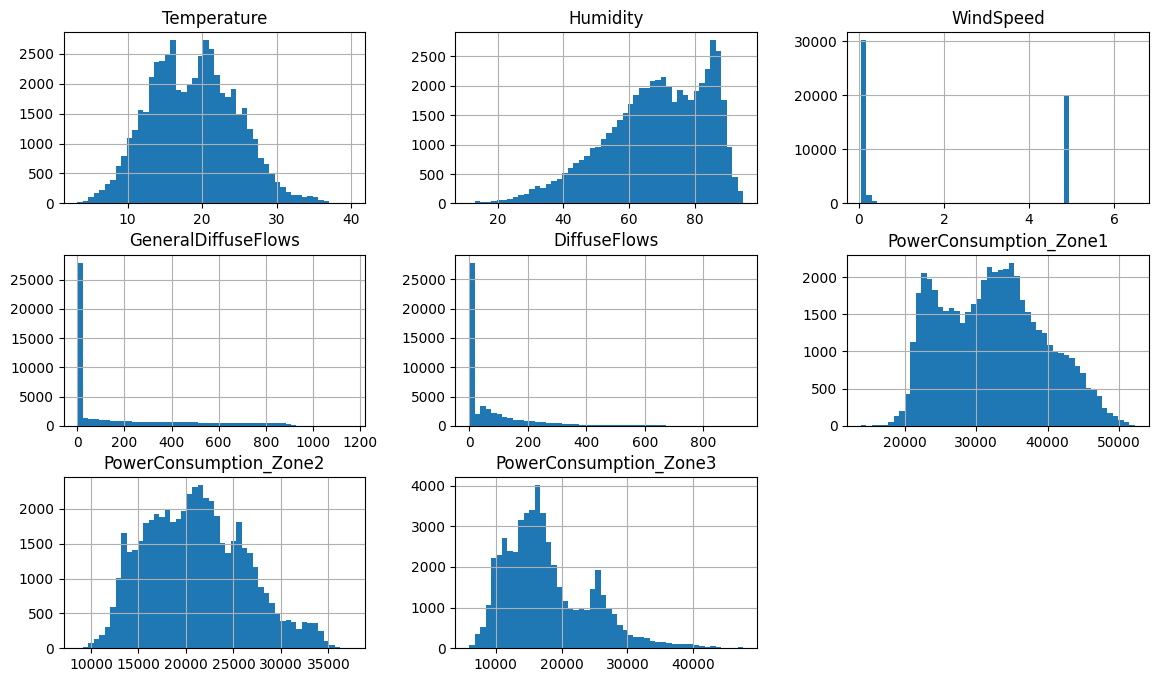

In [6]:
df.hist(bins=50, figsize=(14, 8))
plt.show()

# Opret flere features

Med udganspunkt i power consumption zoner:
    Total og average power consumption på tværs af zoner

Med udgangspunkt i Datetime:
    minute/hour/day/week/month/year variationer

In [7]:
# Total power consumption across all zones
df["Total_PowerConsumption"] = (
    df["PowerConsumption_Zone1"] + 
    df["PowerConsumption_Zone2"] + 
    df["PowerConsumption_Zone3"]
)

# Average power consumption across all zones
df["Average_PowerConsumption"] = df["Total_PowerConsumption"] / 3

# Print(df.head())

In [8]:
# Convert Datetime column to datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Within an hour
df['minute_of_hour'] = df['Datetime'].dt.minute

# Within a day
df['minute_of_day'] = df['Datetime'].dt.hour * 60 + df['Datetime'].dt.minute
df['hour_of_day'] = df['Datetime'].dt.hour

# Within a week
df['day_of_week'] = df['Datetime'].dt.dayofweek
df['minute_of_week'] = df['day_of_week'] * 1440 + df['minute_of_day']

# Within a month
df['minute_of_month'] = (df['Datetime'].dt.day - 1) * 1440 + df['minute_of_day']
df['day_of_month'] = df['Datetime'].dt.day

# Within a year
df['minute_of_year'] = (df['Datetime'].dt.dayofyear -1) * 1440 + df['minute_of_day']
df['hour_of_year'] = (df['Datetime'].dt.dayofyear -1) * 24 + df['hour_of_day']
df['day_of_year'] = df['Datetime'].dt.dayofyear
df['week_of_year'] = df['Datetime'].dt.isocalendar().week
df['month'] = df['Datetime'].dt.month
df['year'] = df['Datetime'].dt.year

samtlige_tid_features = [
    'minute_of_hour', 'minute_of_day', 'hour_of_day', 'minute_of_week', 'day_of_week', 
    'minute_of_month', 'day_of_month', 'minute_of_year', 'hour_of_year', 'day_of_year', 
    'week_of_year', 'month', 'year']

print(df[['minute_of_month', 'day_of_month', 'minute_of_day']][4463:44467])
print(df[samtlige_tid_features].head(10),(df[samtlige_tid_features][32995:33005]),df[samtlige_tid_features].tail(10))

       minute_of_month  day_of_month  minute_of_day
4463             44630            31           1430
4464                 0             1              0
4465                10             1             10
4466                20             1             20
4467                30             1             30
...                ...           ...            ...
44462             6860             5           1100
44463             6870             5           1110
44464             6880             5           1120
44465             6890             5           1130
44466             6900             5           1140

[40004 rows x 3 columns]
   minute_of_hour  minute_of_day  hour_of_day  minute_of_week  day_of_week  \
0               0              0            0            8640            6   
1              10             10            0            8650            6   
2              20             20            0            8660            6   
3              30             30      

---

# Cycklisk encode hver tidsmæssig feature

In [9]:
# 1. Definer Features
# Vi sikrer os, at vi kun bruger de udvalgte features
numeric_features = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows']
cyclical_features = ['minute_of_hour', 'minute_of_day', 'minute_of_week', 'minute_of_year']#, 'month'] 
# På baggrund af, at samtlige af DateTime features er cycliske af natur vælger vi at code dem cyclisk
# I og med at der mangler en enkelt dag i årshjulet svarende til 1440 noteringer af 10-minutters intervaller, så er det stadig repræsentativt nok, vil vi argumentere for.

# check cykliske features værdier før transformation
print((df[cyclical_features].head(10)), (df[cyclical_features][32995:33005]), (df[cyclical_features].tail(10)))
print('_____________________________________')

df['minute_of_hour_sin'] = np.sin(2 * np.pi * df['minute_of_hour'] / 60)
df['minute_of_hour_cos'] = np.cos(2 * np.pi * df['minute_of_hour'] / 60)

df['minute_of_day_sin'] = np.sin(2 * np.pi * df['minute_of_day'] / 1440)
df['minute_of_day_cos'] = np.cos(2 * np.pi * df['minute_of_day'] / 1440)

df['minute_of_week_sin'] = np.sin(2 * np.pi * df['minute_of_week'] / (1440 * 7))
df['minute_of_week_cos'] = np.cos(2 * np.pi * df['minute_of_week'] / (1440 * 7))

df['minute_of_year_sin'] = np.sin(2 * np.pi * df['minute_of_year'] / (1440 * 364))
df['minute_of_year_cos'] = np.cos(2 * np.pi * df['minute_of_year'] / (1440 * 364))

numeric_features = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows']
cyclical_features = ['minute_of_hour_sin', 'minute_of_hour_cos', 
                     'minute_of_day_sin', 'minute_of_day_cos', 
                     'minute_of_week_sin', 'minute_of_week_cos', 
                     'minute_of_year_sin', 'minute_of_year_cos']

# check cykliske features værdier efter transformation
print((df[cyclical_features].head(10)), (df[cyclical_features][32995:33005]), (df[cyclical_features].tail(10)))


   minute_of_hour  minute_of_day  minute_of_week  minute_of_year
0               0              0            8640               0
1              10             10            8650              10
2              20             20            8660              20
3              30             30            8670              30
4              40             40            8680              40
5              50             50            8690              50
6               0             60            8700              60
7              10             70            8710              70
8              20             80            8720              80
9              30             90            8730              90        minute_of_hour  minute_of_day  minute_of_week  minute_of_year
32995              10            190            5950          329950
32996              20            200            5960          329960
32997              30            210            5970          329970
32998    

### plotter cyclisk fordeling

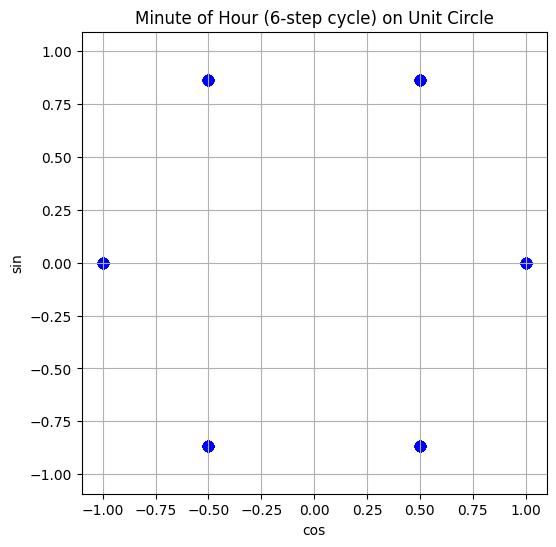

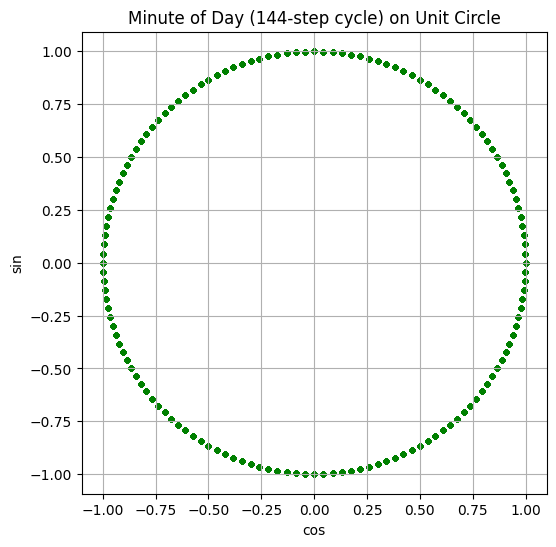

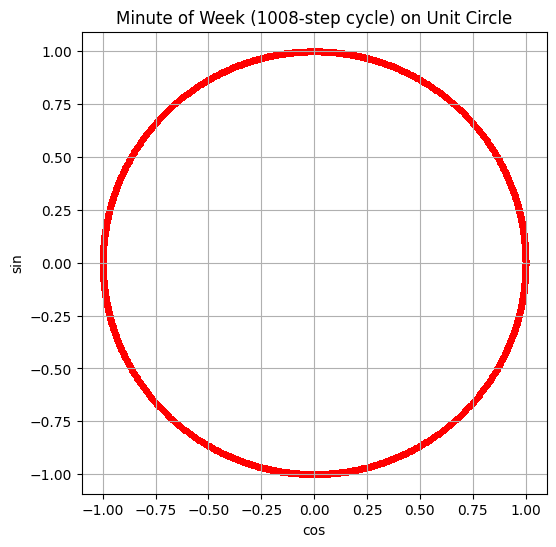

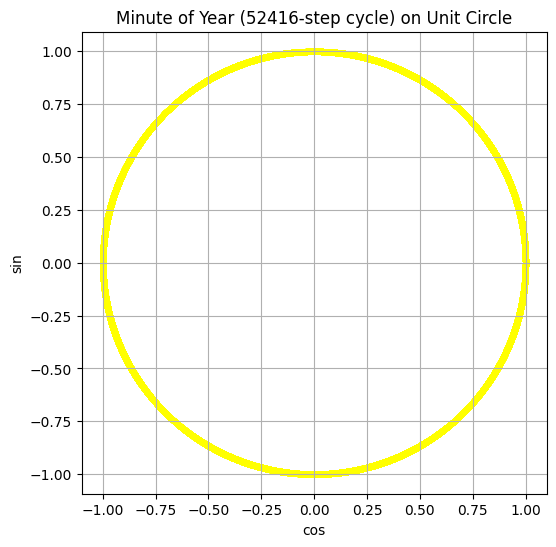

In [10]:
hour_sin = df['minute_of_hour_sin']
hour_cos = df['minute_of_hour_cos']

day_sin = df['minute_of_day_sin']
day_cos = df['minute_of_day_cos']

week_sin = df['minute_of_week_sin']
week_cos = df['minute_of_week_cos']

year_sin = df['minute_of_year_sin']
year_cos = df['minute_of_year_cos']


# Scatter plot for minute_of_hour
plt.figure(figsize=(6,6))
plt.scatter(hour_cos, hour_sin, c='blue', s=50)
plt.title("Minute of Hour (6-step cycle) on Unit Circle")
plt.xlabel("cos")
plt.ylabel("sin")
plt.axis('equal')  # makes circle appear circular
plt.grid(True)
plt.show()

# Scatter plot for minute_of_day
plt.figure(figsize=(6,6))
plt.scatter(day_cos, day_sin, c='green', s=10)
plt.title("Minute of Day (144-step cycle) on Unit Circle")
plt.xlabel("cos")
plt.ylabel("sin")
plt.axis('equal')
plt.grid(True)
plt.show()

# Scatter plot for minute_of_day
plt.figure(figsize=(6,6))
plt.scatter(week_cos, week_sin, c='red', s=10)
plt.title("Minute of Week (1008-step cycle) on Unit Circle")
plt.xlabel("cos")
plt.ylabel("sin")
plt.axis('equal')
plt.grid(True)
plt.show()

# Scatter plot for minute_of_day
plt.figure(figsize=(6,6))
plt.scatter(year_cos, year_sin, c='yellow', s=10)
plt.title("Minute of Year (52416-step cycle) on Unit Circle")
plt.xlabel("cos")
plt.ylabel("sin")
plt.axis('equal')
plt.grid(True)
plt.show()

---

# Træn/Test split

In [11]:

'''__RANDOM SHUFFLED SPLIT:__'''

# X = df[numeric_features + cyclical_features].copy()
# y = df['Total_PowerConsumption'].copy()

# Strategi 1: 
# Først splitter vi i Train+Val (80%) og Test (20%)
# Vi stratificerer ud fra sæson for at sikre en repræsentativ sæson-distribution

# X_train_val, X_test, y_train_val, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     shuffle=True,
#     stratify=None, # df['season'] 
# )

# Hernæst splitter vi Train+Val i Train (80% af 80% = 64%) og Validation (20% af 80% = 16%)
# Vi anvender X_train_val og sikrer en meningsfuld sæson-distribution ved at stratificerer ud fra sæson igen.

# X_train, X_val, y_train, y_val = train_test_split(
#     X_train_val, y_train_val,
#     test_size=0.2,
#     random_state=42,
#     shuffle=True,
#     stratify=None, 
# )

'''__TIMEBASED SPLIT:__'''

train_idx = []
val_idx = []
test_idx = []

for period, group in df.groupby('month'):
    n_rows = len(group)
    n_test = int(np.ceil(0.20 * n_rows))
    n_val = int(np.ceil(0.16 * n_rows))
    n_train = n_rows - n_val - n_test
    
    train_idx.extend(group.index[:n_train])
    val_idx.extend(group.index[n_train:n_train+n_val])
    test_idx.extend(group.index[n_train+n_val:])
    
train_df = df.loc[train_idx].copy()
val_df = df.loc[val_idx].copy()
test_df = df.loc[test_idx].copy()

# Features and target
features = numeric_features + cyclical_features
target = 'Total_PowerConsumption'

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 33535, Val: 8396, Test: 10485


---

# Preprocessing af data (Lineær regression, kNN, Random Forest)

Vi definerer vores input features (X) og target (y).
VI forbereder data til cross validation udelukkende med brug af træningsdata(hverken val- eller test-data)

### Overordnet preprocessing for alle tre valgte modeller 

### Lineær regression, kNNRegressor og RandomForestRegressor preprocessing (skalering a vejrfeatures)

In [12]:
from sklearn.preprocessing import StandardScaler

# Initialiser scaler
std_scaler = StandardScaler()

X_train_std_scaled = X_train.copy()
X_val_std_scaled = X_val.copy()
X_test_std_scaled = X_test.copy()

# Fit standardscaler kun på træningssæt 
# Dernæst transformer både træningssæt, valideringssæt, testsæt
X_train_std_scaled[numeric_features] = std_scaler.fit_transform(X_train_std_scaled[numeric_features])
X_val_std_scaled[numeric_features] = std_scaler.transform(X_val_std_scaled[numeric_features])
X_test_std_scaled[numeric_features] = std_scaler.transform(X_test_std_scaled[numeric_features])

print(X_train_std_scaled.head())




   Temperature  Humidity  WindSpeed  GeneralDiffuseFlows  DiffuseFlows  \
0    -2.094147  0.297964  -0.678089            -0.683195     -0.616963   
1    -2.119036  0.343360  -0.678089            -0.683121     -0.617238   
2    -2.136372  0.343360  -0.679435            -0.683152     -0.617116   
3    -2.169328  0.375785  -0.678089            -0.683040     -0.617149   
4    -2.203658  0.421181  -0.678986            -0.683206     -0.617238   

   minute_of_hour_sin  minute_of_hour_cos  minute_of_day_sin  \
0        0.000000e+00                 1.0           0.000000   
1        8.660254e-01                 0.5           0.043619   
2        8.660254e-01                -0.5           0.087156   
3        5.665539e-16                -1.0           0.130526   
4       -8.660254e-01                -0.5           0.173648   

   minute_of_day_cos  minute_of_week_sin  minute_of_week_cos  \
0           1.000000           -0.781831            0.623490   
1           0.999048           -0.777930  

---

# Model sammenligning

Vi træner tre forskellige regressions-modeller for at finde den bedste model.
Vi bruger cross validation kun indenfor træningssættet til at evaluere og sammenligne modellerne.

Modeller:
- Linear Regression: En simpel baseline model.
- K-Nearest Neighbors (kNN): En instans-baseret læringsmetode.
- Random Forest: En ensemble metode baseret på decision trees.

Metrics: R², RMSE (Root Mean Squared Error) og MAE (Mean Absolute Error).

### cross validation (udelukkende på træningsssæt)

In [13]:
from sklearn.model_selection import cross_val_score, KFold

lr = LinearRegression()
kNN = KNeighborsRegressor()
rf = RandomForestRegressor(random_state=42)

models = [lr, kNN, rf]
metrics = ["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"]

for model in models:
    print(f"{model} scores:")
    for metric in metrics:
        scores = cross_val_score(model, X_train_std_scaled, y_train, cv=5, scoring=metric)
        print(f"{metric}:")
        if metric == metrics[1] or metric == metrics[2]:
            scores*=-1
        print(scores)
        print(f"Mean:", np.mean(scores),"std:",np.std(scores))
        print('')
    print('--------\n')
    



LinearRegression() scores:
r2:
[0.50617854 0.39223268 0.52795025 0.53236569 0.7257171 ]
Mean: 0.5368888520036778 std: 0.10735455073459393

neg_root_mean_squared_error:
[10690.68809681 11119.43709316 12261.51733721 12283.18103753
  7422.38091966]
Mean: 10755.440896876247 std: 1780.3500301494103

neg_mean_absolute_error:
[ 8661.18331183  9130.23853723 10161.02479533  9651.70939748
  5954.60354132]
Mean: 8711.751916639023 std: 1467.2060074610674

--------

KNeighborsRegressor() scores:
r2:
[0.83066022 0.68949613 0.63046635 0.64611097 0.80752054]
Mean: 0.7208508423399979 std: 0.08283508525544615

neg_root_mean_squared_error:
[ 6260.37254547  7947.81297176 10848.69061236 10685.41068342
  6217.79030914]
Mean: 8392.015424431287 std: 2037.811906300992

neg_mean_absolute_error:
[4523.27274208 5477.4451615  7874.17754817 7831.06078658 4807.61275421]
Mean: 6102.713798509087 std: 1462.0635254081894

--------

RandomForestRegressor(random_state=42) scores:
r2:
[0.91591797 0.93184903 0.76374295 0.73

### Feature importance (LR)

In [14]:
from sklearn.inspection import permutation_importance

lr.fit(X_train_std_scaled, y_train)

# train_score = lr.score(X_train_std_scaled[['minute_of_day_sin', 'minute_of_year_cos']], y_train)
# val_score   = lr.score(X_val_std_scaled[['minute_of_day_sin', 'minute_of_year_cos']], y_val)

# print("Train:", train_score)
# print("Val:  ", val_score)

perm = permutation_importance(
    lr,
    X_train_std_scaled,
    y_train,
    n_repeats=10,
    random_state=42
)

importance = pd.Series(perm.importances_mean, index=X_train_std_scaled.columns)\
                .sort_values(ascending=False)

print(importance)

minute_of_day_sin      1.088088
minute_of_year_cos     0.129983
DiffuseFlows           0.041576
WindSpeed              0.023107
Temperature            0.019042
minute_of_week_cos     0.010774
minute_of_week_sin     0.006585
Humidity               0.001995
minute_of_day_cos      0.001324
GeneralDiffuseFlows    0.001207
minute_of_year_sin     0.000337
minute_of_hour_cos     0.000006
minute_of_hour_sin     0.000005
dtype: float64


### Feature importance (kNN)

In [15]:
kNN.fit(X_train_std_scaled, y_train)

N = 2000
kNN_sample_X = X_train_std_scaled.iloc[-N:]
kNN_sample_y = y_train.iloc[-N:]

perm = permutation_importance(
    kNN,
    kNN_sample_X,
    kNN_sample_y,
    n_repeats=8,
    random_state=42
)

importance = pd.Series(perm.importances_mean, index=X_train_std_scaled.columns)\
                .sort_values(ascending=False)

print(importance)

kNN_new_features = []

minute_of_day_sin      1.589414
minute_of_day_cos      0.123288
GeneralDiffuseFlows    0.104297
DiffuseFlows           0.046031
Humidity               0.045730
minute_of_week_sin     0.032138
minute_of_week_cos     0.029080
Temperature            0.018443
WindSpeed              0.003090
minute_of_year_cos    -0.000204
minute_of_year_sin    -0.000896
minute_of_hour_cos    -0.001754
minute_of_hour_sin    -0.004591
dtype: float64


### Feature importance (rnd forest)


In [16]:
# rnd_for_new_features = ['Temperature', 'GeneralDiffuseFlows',  
#                      'minute_of_day_sin', 'minute_of_day_cos',  
#                      'minute_of_year_sin', 'minute_of_year_cos']

# # Fit model on the full training data to get feature importances
# rnd_for.fit(X_train[rnd_for_new_features], y_train)

# # Extract feature importances
# feature_importances = pd.Series(rnd_for.feature_importances_, index=X_train[rnd_for_new_features].columns)
# feature_importances = feature_importances.sort_values(ascending=False)

# print("\nFeature Importances:")
# print(feature_importances)


rf.fit(X_train_std_scaled, y_train)

perm = permutation_importance(
    rf,
    X_train_std_scaled,
    y_train,
    n_repeats=10,
    random_state=42
)

importance = pd.Series(perm.importances_mean, index=X_train_std_scaled.columns)\
                .sort_values(ascending=False)

print(importance)

# EFTER RUN

rf_new_features = ['minute_of_day_sin', 'minute_of_year_cos', 
                   'minute_of_day_cos', 'minute_of_year_sin', 
                   'GeneralDiffuseFlows', 'Temperature']


minute_of_day_sin      1.263733
minute_of_year_cos     0.441582
minute_of_day_cos      0.200790
minute_of_year_sin     0.147164
GeneralDiffuseFlows    0.075857
Temperature            0.055485
minute_of_week_cos     0.016506
minute_of_week_sin     0.013559
DiffuseFlows           0.010887
Humidity               0.002383
WindSpeed              0.001391
minute_of_hour_sin     0.000255
minute_of_hour_cos     0.000179
dtype: float64


### hyperparameter tuning (kNN)

In [17]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

kNN_features = ['minute_of_day_sin', 'minute_of_day_cos', 
                'GeneralDiffuseFlows', 'DiffuseFlows', 
                'Humidity', 'minute_of_week_sin', 
                'minute_of_week_cos', 'Temperature']

X_kNN_train_std_scaled = X_train_std_scaled[kNN_features]
X_kNN_val_std_scaled = X_val_std_scaled[kNN_features]
X_kNN_test_std_scaled = X_test_std_scaled[kNN_features]

knn_param_dist = {
    'n_neighbors': randint(1, 40),              
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'p': [1, 2]                                
}

knn_search = RandomizedSearchCV(
    kNN,
    knn_param_dist,
    n_iter=20,       
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=1,
    random_state=42
)

knn_search.fit(X_kNN_train_std_scaled, y_train)

print("Best parameters:", knn_search.best_params_)
print("Best CV score:", knn_search.best_score_)

best_knn_model = knn_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'metric': 'manhattan', 'n_neighbors': 35, 'p': 2, 'weights': 'uniform'}
Best CV score: 0.7406375484295047


### hyperparameter tuning (RF)

In [18]:

rf_features = ['minute_of_day_sin', 'minute_of_day_cos', 
                'GeneralDiffuseFlows', 'Temperature',
                'minute_of_year_sin', 'minute_of_year_cos']

X_rf_train_std_scaled = X_train_std_scaled[rf_features]
X_rf_val_std_scaled = X_val_std_scaled[rf_features]
X_rf_test_std_scaled = X_test_std_scaled[rf_features]

rf_param_dist = {
    'n_estimators': [100, 200, 300],            
    'max_depth': [None, 20, 40],               
    'min_samples_split': [2, 5, 10],           
    'min_samples_leaf': [1, 2, 4],             
    'max_features': ['sqrt', 'log2'],          
    'bootstrap': [True]   
}

rf_search = RandomizedSearchCV(
    rf,
    rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=1,
    random_state=42
)

rf_search.fit(X_rf_train_std_scaled, y_train)

print("Best parameters:", rf_search.best_params_)

print("Best CV score:", rf_search.best_score_)

best_rf_model = rf_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}
Best CV score: 0.8591598898621091


### test af modeller på validering (r2, MAE, RMSE og Residualplot)


--- KNeighborsRegressor(metric='manhattan', n_neighbors=35) ---
R2_train: 0.9160
R2_val: 0.7963
RMSE_train: 4930.8195
RMSE_val: 7935.8294
MAE_train: 3462.0616
MAE_val: 5481.0643


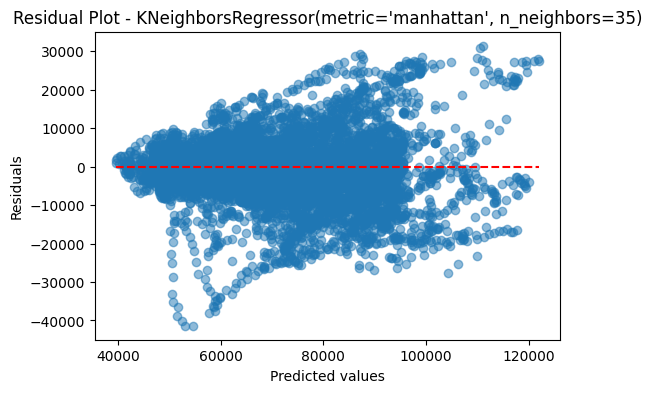



--- RandomForestRegressor(max_depth=20, max_features='log2', min_samples_split=5,
                      random_state=42) ---
R2_train: 0.9978
R2_val: 0.9251
RMSE_train: 791.0888
RMSE_val: 4812.7352
MAE_train: 538.2423
MAE_val: 3333.7063


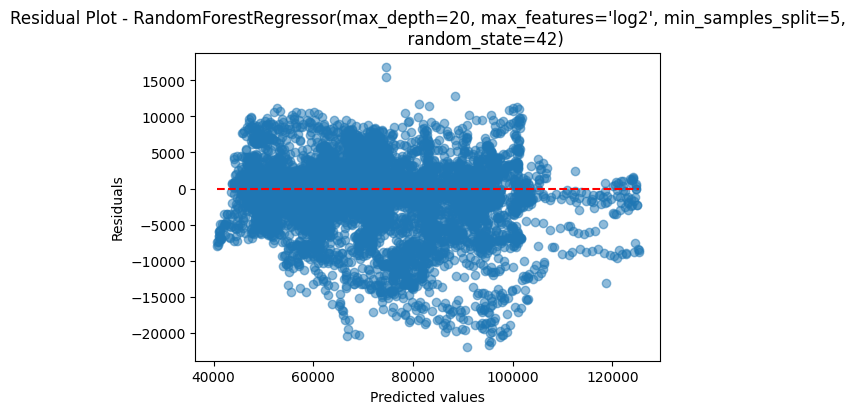

In [19]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np


# forslåede hyperparametre:
kNN = KNeighborsRegressor(metric='manhattan', n_neighbors=35, p=2, weights='uniform') 

# overfit reducering
# kNN = KNeighborsRegressor(metric='manhattan', n_neighbors=115, p=1, weights='uniform')

# forslåede hyperparametre:
rf = RandomForestRegressor(n_estimators=100, min_samples_split=5, min_samples_leaf=1, max_features='log2', max_depth=20, bootstrap=True, random_state=42)

# overfit reducering
# rf = RandomForestRegressor(n_estimators=400, min_samples_split=15, min_samples_leaf=8, max_features='sqrt', max_depth=15, bootstrap=True, random_state=42)


kNN.fit(X_kNN_train_std_scaled, y_train)
rf.fit(X_rf_train_std_scaled, y_train)


print(f"\n--- {kNN} ---")
    
# Predictions
y_train_pred = kNN.predict(X_kNN_train_std_scaled)
y_val_pred = kNN.predict(X_kNN_val_std_scaled)

# Metrics
metrics = {
    'R2_train': r2_score(y_train, y_train_pred),
    'R2_val': r2_score(y_val, y_val_pred),
    'RMSE_train': root_mean_squared_error(y_train, y_train_pred),
    'RMSE_val': root_mean_squared_error(y_val, y_val_pred),
    'MAE_train': mean_absolute_error(y_train, y_train_pred),
    'MAE_val': mean_absolute_error(y_val, y_val_pred)
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# Residual plot
plt.figure(figsize=(6,4))
plt.scatter(y_val_pred, y_val_pred - y_val, alpha=0.5)
plt.hlines(y=0, xmin=min(y_val_pred), xmax=max(y_val_pred), colors='r', linestyles='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {kNN}")
plt.show()




print(f"\n\n--- {rf} ---")
    
# Predictions
y_train_pred = rf.predict(X_rf_train_std_scaled)
y_val_pred = rf.predict(X_rf_val_std_scaled)

# Metrics
metrics = {
    'R2_train': r2_score(y_train, y_train_pred),
    'R2_val': r2_score(y_val, y_val_pred),
    'RMSE_train': root_mean_squared_error(y_train, y_train_pred),
    'RMSE_val': root_mean_squared_error(y_val, y_val_pred),
    'MAE_train': mean_absolute_error(y_train, y_train_pred),
    'MAE_val': mean_absolute_error(y_val, y_val_pred)
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# Residual plot
plt.figure(figsize=(6,4))
plt.scatter(y_val_pred, y_val_pred - y_val, alpha=0.5)
plt.hlines(y=0, xmin=min(y_val_pred), xmax=max(y_val_pred), colors='r', linestyles='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {rf}")
plt.show()


# for name, model in models.items():
#     print(f"\n--- {name} ---")
    
#     # Predictions
#     y_train_pred = model.predict(X_train_std_scaled)
#     y_val_pred = model.predict(X_val_std_scaled)
    
#     # Metrics
#     metrics = {
#         'R2_train': r2_score(y_train, y_train_pred),
#         'R2_val': r2_score(y_val, y_val_pred),
#         'RMSE_train': root_mean_squared_error(y_train, y_train_pred),
#         'RMSE_val': root_mean_squared_error(y_val, y_val_pred),
#         'MAE_train': mean_absolute_error(y_train, y_train_pred),
#         'MAE_val': mean_absolute_error(y_val, y_val_pred)
#     }
    
#     for metric, value in metrics.items():
#         print(f"{metric}: {value:.4f}")
    
#     # Residual plot
#     plt.figure(figsize=(6,4))
#     plt.scatter(y_val_pred, y_val_pred - y_val, alpha=0.5)
#     plt.hlines(y=0, xmin=min(y_val_pred), xmax=max(y_val_pred), colors='r', linestyles='--')
#     plt.xlabel("Predicted values")
#     plt.ylabel("Residuals")
#     plt.title(f"Residual Plot - {name}")
#     plt.show()

### Låser modellerne og træner dem forfra på både trening og valideringslet, og tester nu på test sæt 



--- RandomForestRegressor(max_depth=20, max_features='log2', min_samples_split=5,
                      random_state=42) ---
R2_train: 0.9976
R2_test: 0.9252
RMSE_train: 831.8433
RMSE_test: 4698.0594
MAE_train: 568.8815
MAE_test: 3294.9592


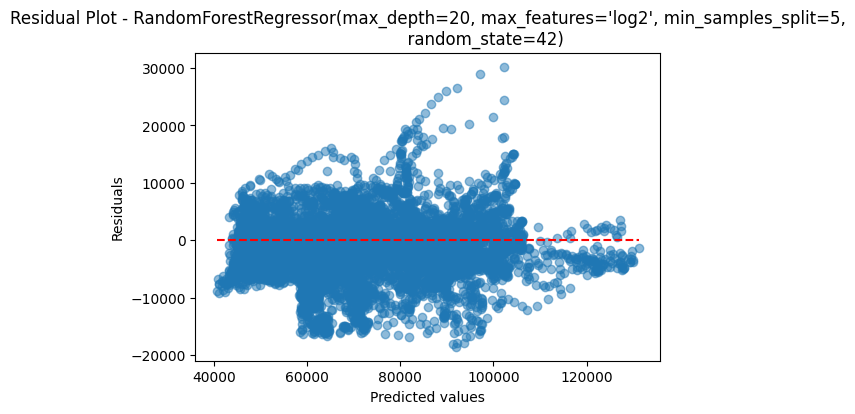

In [20]:
X_rf_train_val_std_scaled = pd.concat([X_rf_train_std_scaled, X_rf_val_std_scaled], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

rf.fit(X_rf_train_val_std_scaled, y_train_val)

# overfit reducering
# rf = RandomForestRegressor(n_estimators=400, min_samples_split=15, min_samples_leaf=8, max_features='sqrt', max_depth=15, bootstrap=True, random_state=42)

print(f"\n\n--- {rf} ---")
    
# Predictions
y_train_val_pred = rf.predict(X_rf_train_val_std_scaled)
y_test_pred = rf.predict(X_rf_test_std_scaled)

# Metrics
metrics = {
    'R2_train': r2_score(y_train_val, y_train_val_pred),
    'R2_test': r2_score(y_test, y_test_pred),
    'RMSE_train': root_mean_squared_error(y_train_val, y_train_val_pred),
    'RMSE_test': root_mean_squared_error(y_test, y_test_pred),
    'MAE_train': mean_absolute_error(y_train_val, y_train_val_pred),
    'MAE_test': mean_absolute_error(y_test, y_test_pred)
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# Residual plot
plt.figure(figsize=(6,4))
plt.scatter(y_test_pred, y_test_pred - y_test, alpha=0.5)
plt.hlines(y=0, xmin=min(y_test_pred), xmax=max(y_test_pred), colors='r', linestyles='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {rf}")
plt.show()


### omdan til tærskelværdier

76386.9421315
134208.14595
36785.039739
71222.88586428425
69788.79094
17143.138963686677
0        noPeak
1        noPeak
2        noPeak
3        noPeak
4        noPeak
          ...  
52411    noPeak
52412    noPeak
52413    noPeak
52414    noPeak
52415    noPeak
Name: peak_status, Length: 52416, dtype: object
peak_status
noPeak    35119
peak      17297
Name: count, dtype: int64


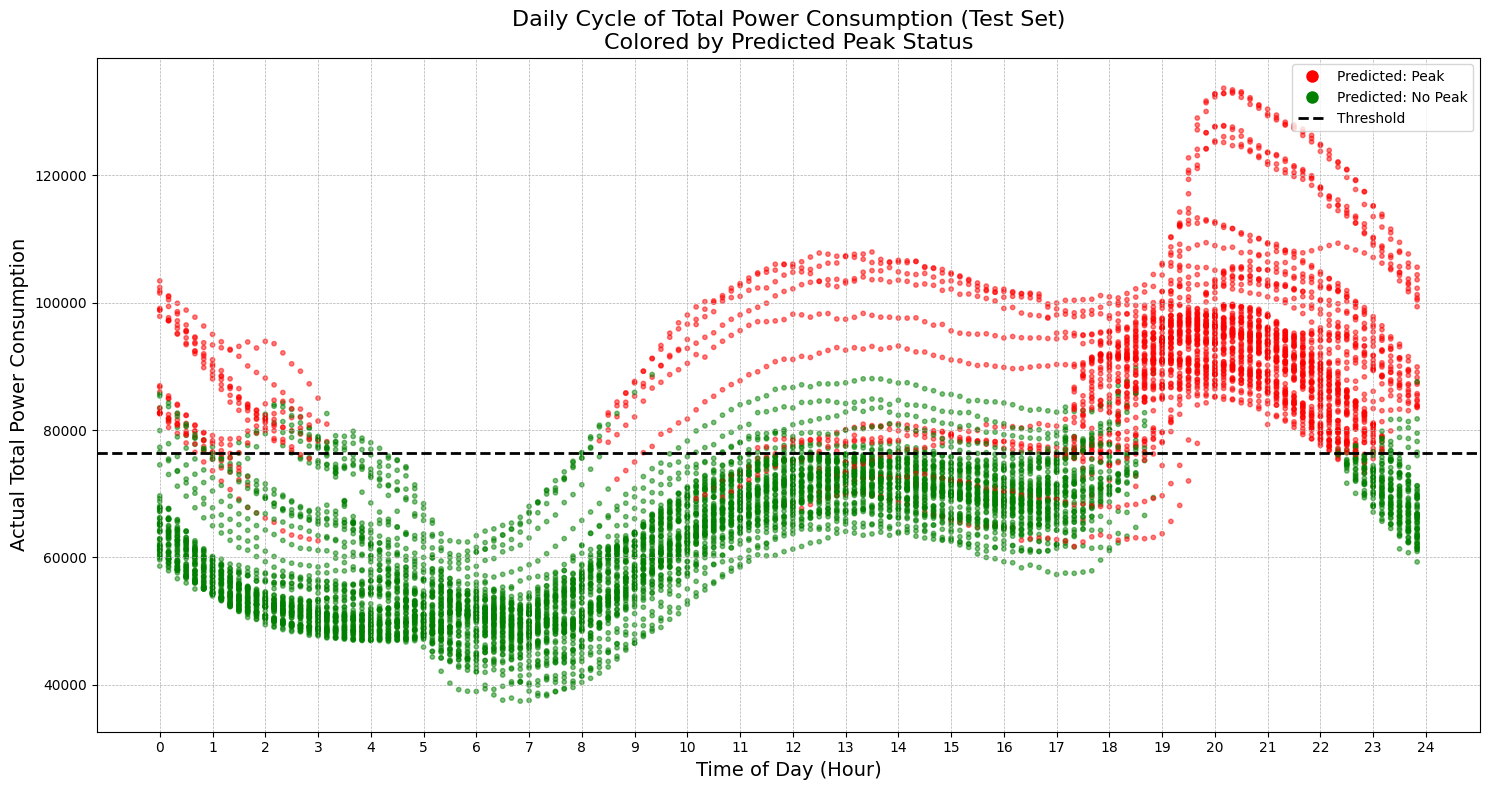

In [21]:

# Get 67th percentile directly
percentile_67 = df['Total_PowerConsumption'].quantile(0.67)
print(percentile_67)
print(df['Total_PowerConsumption'].max())
print(df['Total_PowerConsumption'].min())
print(df['Total_PowerConsumption'].mean())
print(df['Total_PowerConsumption'].median())
print(df['Total_PowerConsumption'].std())

df['peak_status'] = df['Total_PowerConsumption'].apply(lambda x: 'peak' if x > percentile_67 else 'noPeak')

print(df['peak_status'])
print(df['peak_status'].value_counts())

# Determine colors based on Prediction
# Logic: If Pred > Threshold -> Peak (Red), Else NoPeak (Green)
pred_is_peak = y_test_pred > percentile_67
colors = np.where(pred_is_peak, 'red', 'green')


# X-axis: TimeOfDay from test set
x_axis = test_df['minute_of_day'] / 60.0

# Plotting
plt.figure(figsize=(15, 8))
plt.scatter(x_axis, y_test, c=colors, alpha=0.5, s=10, label='Test Data Points')

# Add threshold line for reference
plt.axhline(y=percentile_67, color='black', linestyle='--', linewidth=2, label='67th Percentile Threshold')

plt.title('Daily Cycle of Total Power Consumption (Test Set)\nColored by Predicted Peak Status', fontsize=16)
plt.xlabel('Time of Day (Hour)', fontsize=14)
plt.ylabel('Actual Total Power Consumption', fontsize=14)
plt.xticks(np.arange(0, 25, 1))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Create a custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Predicted: Peak', markersize=10),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='Predicted: No Peak', markersize=10),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='Threshold')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('power_consumption_daily_cycle.png')




### Confusion matrix og performance measures

3571     1
3572     1
3573     1
3574     1
3575     1
        ..
52411    0
52412    0
52413    0
52414    0
52415    0
Name: Total_PowerConsumption, Length: 10485, dtype: int64
[1 1 1 ... 0 0 0]
Confusion Matrix:
[[6818  204]
 [ 430 3033]]
TP: 3033, FP: 204, TN: 6818, FN: 430

Metrics:
Accuracy: 0.94
Recall (Sensitivity, TPR): 0.88
Precision (PPV): 0.94
Specificity (TNR): 0.97
Negative Predictive Value (NPV): 0.94
F1 score: 0.91
[0.         0.02905155 1.        ] [0.         0.87583021 1.        ] [inf  1.  0.]
AUC: 0.92


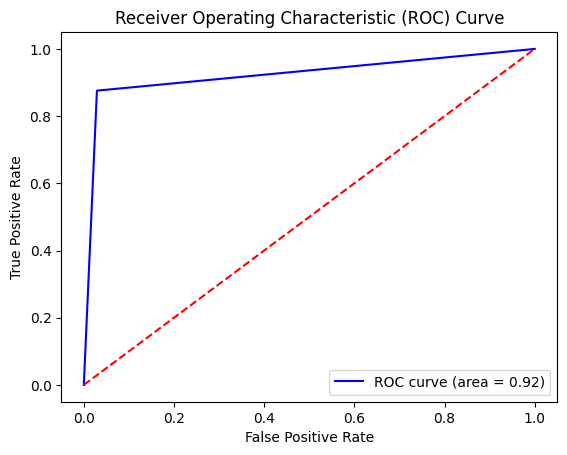

In [22]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, roc_curve, auc, f1_score

# Example y_test and y_test_pred (replace these with your actual data)
y_test_class = y_test.apply(lambda x: 1 if x > percentile_67 else 0)
y_test_pred_class = np.where(y_test_pred > percentile_67, 1, 0)

print(y_test_class)
print(y_test_pred_class)

# Confusion Matrix
cm = confusion_matrix(y_test_class, y_test_pred_class)
tn, fp, fn, tp = cm.ravel()  # unpack the confusion matrix

print("Confusion Matrix:")
print(cm)
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")

# Basic metrics
accuracy = accuracy_score(y_test_class, y_test_pred_class)
recall = recall_score(y_test_class, y_test_pred_class)  # also called sensitivity or TPR
precision = precision_score(y_test_class, y_test_pred_class)  # also called positive predictive value (PPV)

# Additional metrics
specificity = tn / (tn + fp)  # True Negative Rate
npv = tn / (tn + fn)  # Negative Predictive Value

f1 = f1_score(y_test_class, y_test_pred_class)  

print("\nMetrics:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Recall (Sensitivity, TPR): {recall:.2f}")
print(f"Precision (PPV): {precision:.2f}")
print(f"Specificity (TNR): {specificity:.2f}")
print(f"Negative Predictive Value (NPV): {npv:.2f}")
print(f"F1 score: {f1:.2f}")


# ROC and AUC

# brug sæt af probabilities i stedet for labels
fpr, tpr, thresholds = roc_curve(y_test_class, y_test_pred_class)
roc_auc = auc(fpr, tpr)

print(fpr, tpr, thresholds)

print(f"AUC: {roc_auc:.2f}")

# Optional: plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()